<a href="https://colab.research.google.com/github/Ty700/STAT_650/blob/main/Tyler_Scotti_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="logo-statistics-horizontal-maroon-box-black-1.png" WIDTH=200 ALIGN="right"> </figure>

## STAT 650: HW3
    
*Developed by Yoonsung Jung*

## Basics of Python

- **Due**: posted in CANVAS
- **Submission**: submit two files (.ipynb and .html or .pdf or. docx)
  

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as rnd

### Q1. Throwing a dice

- Simulate throwing a dice 100 times and report how many times you throw 1, 2, 3, 4, 5, and 6. Your reported values should add up to 100.

- Make sure to use a loop to generate your simulation.

In [2]:
# simulate throwing a die 100 times
# gonna use a loop like the prof wants

rolls = np.zeros(100, dtype=int)

for i in range(100):
    rolls[i] = rnd.randint(1, 7)  # random int from 1 to 6

# count how many times each face showed up
total = 0
for face in range(1, 7):
    count = np.count_nonzero(rolls == face)
    total += count
    print(f'number of times {face} is {count}')

print(f'\ntotal number of throws  {total}')


number of times 1 is 15
number of times 2 is 21
number of times 3 is 18
number of times 4 is 16
number of times 5 is 17
number of times 6 is 13

total number of throws  100


### Q2. Flipping a coin

1. Flipping a coin five times:

- Simulate flipping a coin five times. Record how many times you obtain tails (varying from 0-5).

- Perform the experiment 1000 times, and record the percent of tails you get in each experiment.

- Make a bar graph of the results from the 1000 experiments. The total number of tails  should be on the horizontal axis and the experimentally computed probability to get that many tails (the percents), on the vertical axis.

*Note: You can Execute your code several times (hit [shift]-[enter]) and see that the graph changes a bit every time, as the sequence of random numbers changes every time.*

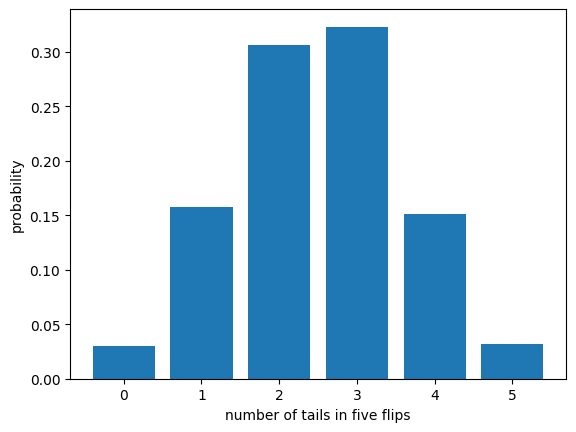

In [3]:
N = 1000

# do the coin flip experiment 1000 times
# each experiment = flip 5 coins, count tails
tail_counts = np.zeros(6)  # bins for 0,1,2,3,4,5 tails

for i in range(N):
    flips = rnd.randint(0, 2, size=5)  # 0=heads, 1=tails
    num_tails = np.sum(flips)
    tail_counts[num_tails] += 1

# convert to probabilities
probs = tail_counts / N

plt.bar(range(6), probs)
plt.xlabel('number of tails in five flips')
plt.ylabel('probability');


2. Cummulative probabilities:
- Compute the cumulative probability table for values from 0 to 5 and print the values to the screen.
- Make a plot of the cumulative probability function using a bar graph.

Cumulative probability table:
  P(tails <= 0) = 0.0300
  P(tails <= 1) = 0.1880
  P(tails <= 2) = 0.4940
  P(tails <= 3) = 0.8170
  P(tails <= 4) = 0.9680
  P(tails <= 5) = 1.0000


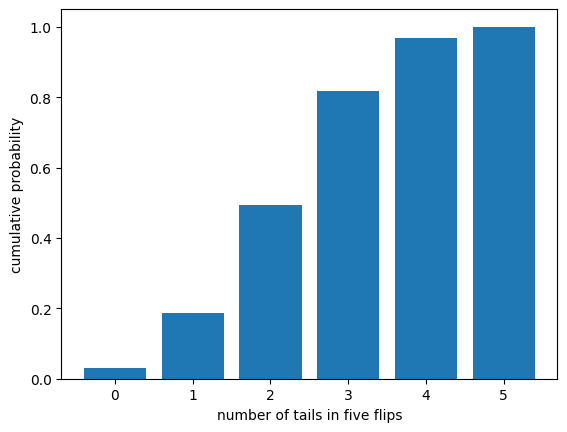

In [4]:
# cumulative probabilities
cum_probs = np.cumsum(probs)

print('Cumulative probability table:')
for i in range(6):
    print(f'  P(tails <= {i}) = {cum_probs[i]:.4f}')

plt.bar(range(6), cum_probs)
plt.xlabel('number of tails in five flips')
plt.ylabel('cumulative probability');


### Q3. Flipping a coin revisited

Go back to the experiment where we flip a coin five times in a row and record how many times we obtain tails.

- Compute the theoretical probability for 0, 1, 2, 3, 4, and 5 tails.
- Compare your answer to the probability computed from 1000 trials, 10000 trials, and 100000 trials (use a loop for these three sets of trials).
- Do you approach the theoretical value with more trials?

In [5]:
from scipy.special import comb

print('Theoretical probabilities:')
pexact = np.empty(6)

# binomial probs: C(5,k) * (0.5)^5
for k in range(6):
    pexact[k] = comb(5, k) * (0.5)**5

print(f'\nExact probability: {pexact}')


Theoretical probabilities:

Exact probability: [0.03125 0.15625 0.3125  0.3125  0.15625 0.03125]


Theoretical probabilities:

In [6]:
# compare theoretical vs simulated at different trial counts

for N in [1000, 10000, 100000]:
    psim = np.zeros(6)
    for i in range(N):
        flips = rnd.randint(0, 2, size=5)
        num_tails = np.sum(flips)
        psim[num_tails] += 1
    psim = psim / N
    print(f'Probability with {N} trials: {psim}')

# yep more trials = closer to theoretical, law of large numbers baby


Probability with 1000 trials: [0.031 0.167 0.317 0.31  0.145 0.03 ]
Probability with 10000 trials: [0.0335 0.1616 0.3117 0.309  0.1514 0.0328]
Probability with 100000 trials: [0.0316  0.15311 0.31582 0.31204 0.15629 0.03114]


__Output Format:__
```
Theoretical probabilities:

Exact probability: [0.xxxxx 0.xxxxx 0.xxxxx  0.xxxxx  0.xxxxx 0.xxxxx]

Probability with 1000 trials: [0.xxxxx 0.xxxxx 0.xxxxx  0.xxxxx  0.xxxxx 0.xxxxx]

Probability with 10000 trials: [0.xxxxx 0.xxxxx 0.xxxxx  0.xxxxx  0.xxxxx 0.xxxxx]

Probability with 100000 trials: [0.xxxxx 0.xxxxx 0.xxxxx  0.xxxxx  0.xxxxx 0.xxxxx]
```

### Q4. Election poll

1. Consider an election where one million people will vote. The true election results are that 490,000 people vote for candidate $A$ and 510,000 people vote for candidate $B$. Consider a scenario in which 'Maurice the Dog' chooses the winner by conducting a poll among 1000 randomly chosen voters (assume these voters follow the distribution of the true election results).

- Simulate a poll by the Dog, and output the predicted winner (use a seed of 2).

In [7]:
rnd.seed(2)

# 490k for A, 510k for B
population = np.array(['A'] * 490000 + ['B'] * 510000)

# the dog polls 1000 random voters
poll = rnd.choice(population, 1000)
polled_for_A = np.count_nonzero(poll == 'A')

print('polled for A:', polled_for_A)
if polled_for_A > 500:
    print('The Dog will predict the wrong winner')
else:
    print('The Dog will predict the correct winner')


polled for A: 508
The Dog will predict the wrong winner


2. Simulate 1000 polls of 1000 people.
   
- Perform the poll 1000 times and record the outcome of the poll (which candidate is predicted to win).

- From your 1000 simulated polls: output how many times candidate $A$ is predicted to win and how many times candidate $B$ is predicted to win.

- What is the probability that the Dog will predict the correct winner based on these 1000 polls of 1000 people?

In [8]:
Awins = 0
Bwins = 0

# run 1000 polls of 1000 people each
for i in range(1000):
    poll = rnd.choice(population, 1000)
    polled_for_A = np.count_nonzero(poll == 'A')
    if polled_for_A > 500:
        Awins += 1
    else:
        Bwins += 1

print('1000 polls of 1000 people')
print('Probability that The Dog predicts candidate A to win:', Awins / 1000)
print('Probability that The Dog predicts candidate B to win:', Bwins / 1000)


1000 polls of 1000 people
Probability that The Dog predicts candidate A to win: 0.267
Probability that The Dog predicts candidate B to win: 0.733


3. Simulate 1000 polls of 5000 people.

- Now, simulate the probability that the Dog will predict the correct winner based on 1000 polls of 5000 people.

- Does the probability that The Dog predicts the correct winner increase significantly when he polls 5000 people vs. 1000 people?

In [9]:
Awins = 0
Bwins = 0

# same deal but 5000 people per poll now
for i in range(1000):
    poll = rnd.choice(population, 5000)
    polled_for_A = np.count_nonzero(poll == 'A')
    if polled_for_A > 2500:  # updated threshold for 5000 people
        Awins += 1
    else:
        Bwins += 1

print('1000 polls of 5000 people')
print('Probability that The Dog predicts candidate A to win:', Awins / 1000)
print('Probability that The Dog predicts candidate B to win:', Bwins / 1000)

# way more accurate with 5000 people, bigger sample ftw


1000 polls of 5000 people
Probability that The Dog predicts candidate A to win: 0.07
Probability that The Dog predicts candidate B to win: 0.93


### Q5. First histogram

- Generate 1000 random numbers from a Normal distribution with mean 100 and standard deviation 10.
- Compute and print the mean and standard deviation of your data.
- Create two graphs above each other using the `plt.subplot` command.
    - In the top graph, plot a histogram using 20 bins going from 50 to 150.
    - Add a red line representing the probability density function of the underlying normal distribution to the graph.
    - In the bottom graph, draw a histogram of the cumulative distribution function, by setting the keyword `cumulative=True` (see `plt.hist?` for details).
    - For the bottom graph, use the keyword `align='right'` so that the bars are centered on the right bin edges (so that the line you are drawing next will approximately go through the centers of the bars).
    - Add a red line representing the cumulative distribution function of the underlying normal distribution to the graph using the `norm.cdf` function, which works the same as the `norm.pdf` function but computes the cumulative distribution function (cdf).
    - Finally, make sure the limits along the horizontal axis are the same for both graphs.

*Note that with this size of a data set (1000 data points), the histogram starts to look a lot more like the typical bell-shaped curve of a Normal distribution.*


In [10]:
from scipy.stats import norm

mu = 100
sig = 10

# generate 1000 random numbers from N(100, 10)
data = rnd.normal(mu, sig, 1000)

print(f'mean of data is: {np.mean(data):.4f}')
print(f'standard deviation of data is: {np.std(data):.4f}')


mean of data is: 100.0083
standard deviation of data is: 10.4857


Output Format:
> mean of data is: (Mean Value) \
  standard deviation of data is: (STD value)

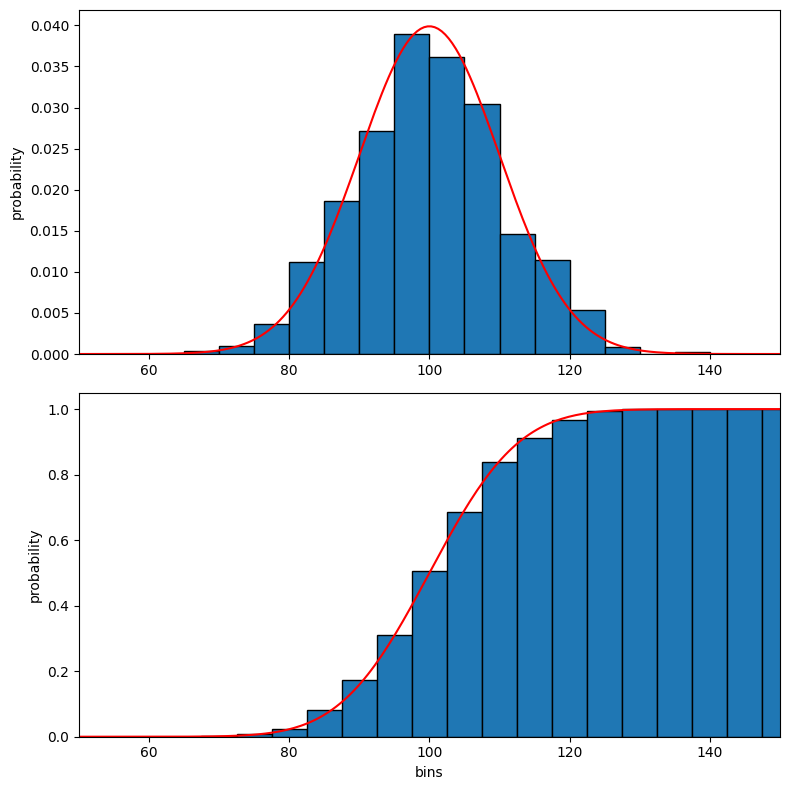

In [11]:
# both plots in one figure so they stack nicely
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# top plot - histogram + PDF
ax1.hist(data, bins=20, range=(50, 150), density=True, edgecolor='black')
x = np.linspace(50, 150, 200)
ax1.plot(x, norm.pdf(x, mu, sig), 'r')
ax1.set_xlim(50, 150)
ax1.set_ylabel('probability')

# bottom plot - cumulative histogram + CDF
ax2.hist(data, bins=20, range=(50, 150), density=True, cumulative=True,
         align='right', edgecolor='black')
ax2.plot(x, norm.cdf(x, mu, sig), 'r')
ax2.set_xlim(50, 150)
ax2.set_xlabel('bins')
ax2.set_ylabel('probability')

plt.tight_layout();


In [12]:
# Part 1. Finding theoretical IQR vs IQR of data
mu = 20
sig = 4

# theoretical quartiles from the inverse cdf
q25_theory = norm.ppf(0.25, mu, sig)
q75_theory = norm.ppf(0.75, mu, sig)
print(f'theoretical IQR: ({q25_theory:.4f}, {q75_theory:.4f})')

# generate 100 data points
data6 = rnd.normal(mu, sig, 100)

# empirical quartiles
q25_data = np.quantile(data6, 0.25)
q75_data = np.quantile(data6, 0.75)
print(f'IQR of data: ({q25_data:.4f}, {q75_data:.4f})')


theoretical IQR: (17.3020, 22.6980)
IQR of data: (17.4488, 21.6881)


Output Format:
> theoretical IQR: ( , ) \
  IQR of data: ( , )

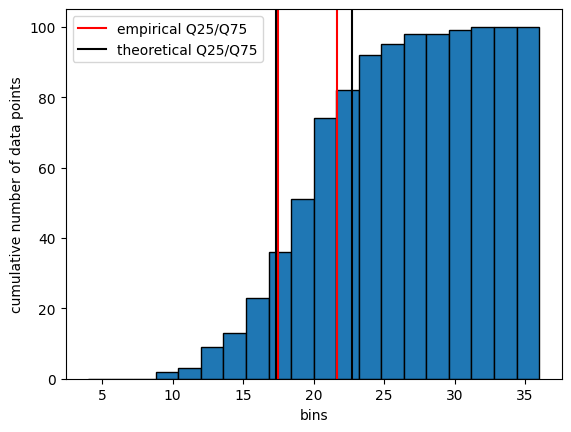

In [13]:
# Part 2. Graph
bins6 = np.linspace(mu - 4*sig, mu + 4*sig, 21)
plt.hist(data6, bins=bins6, cumulative=True, edgecolor='black')

# red lines = empirical quartiles
plt.axvline(q25_data, color='red', label='empirical Q25/Q75')
plt.axvline(q75_data, color='red')

# black lines = theoretical quartiles
plt.axvline(q25_theory, color='black', label='theoretical Q25/Q75')
plt.axvline(q75_theory, color='black')

plt.legend()
plt.xlabel('bins')
plt.ylabel('cumulative number of data points');


### Q7. Loading experimental data and basic operations

### Dataset of experiments on wooden beams
A data set of 356 experiments on wooden beams, specifically Douglas Firs, is provided in the file `douglas_data.csv` (data courtesy Geert Ravenhorst, Timber Structures, Civil Engineering and Geosciences, TU Delft). The file contains 9 columns separated by commas. The first line (line number 0) of the file contains the names of the columns. The second line (line number 1) contains information about the units of the data (we won't load this information).  The first column has the name of the sample (`sample`), followed by: the moisture percentage (`moisture`), the knot ratio (`knotratio`), the tree ring width in mm (`treering`), the dynamic elasticity modulus in N/mm$^2$ (`Edyn`), the density of the wood in kg/m$^3$ (`density`), the beam height in mm (`beamheight`), the static elasticity modulus in N/mm$^2$ (`Estat`), and finally the bending strength in N/mm$^2$ (`bstrength`). A more extensive description of these different data is given when they are used.

- Load the data in the file `douglas_data.csv` using the `read_csv` command of the `pandas` package (see the `pandas` Notebook if you forgot how).
- Use the `skiprows` and `skipinitialspace` keywords.

Carry out the following three tasks:

1. Determine and report the minimum and maximum measured values of the bending strength.

In [14]:
from pandas import read_csv

w = read_csv('douglas_data.csv', skiprows=[1], skipinitialspace=True)
w.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sample      356 non-null    object 
 1   moisture    356 non-null    float64
 2   knotratio   356 non-null    float64
 3   treering    356 non-null    float64
 4   Edyn        356 non-null    int64  
 5   density     356 non-null    int64  
 6   beamheight  356 non-null    int64  
 7   Estat       356 non-null    int64  
 8   bstrength   356 non-null    float64
dtypes: float64(4), int64(4), object(1)
memory usage: 25.2+ KB


2. Determine and report the mean and standard deviation of the density.

In [15]:
# min and max bending strength
print(f'minimum bending strength: {w["bstrength"].min()}')
print(f'maximum bending strength: {w["bstrength"].max()}')


minimum bending strength: 15.66
maximum bending strength: 101.53


3. Determine and report the 0.25, 0.5, and 0.975 quantiles of the tree ring width.

In [16]:
# mean and std of density
print(f'mean density: {w["density"].mean():.4f}')
print(f'standard deviation of density: {w["density"].std():.4f}')


mean density: 575.7247
standard deviation of density: 62.0074


### Q8. Boxplot of moisture content

The moisture content is defined as the mass of moisture in a beam divided by the total mass of the beam (including the moisture) and is recorded as a percentage.

- Compute and report the mean and standard deviation of the moisture content, and make a box plot.

3. Determine and report the 0.25, 0.5, and 0.975 quantiles of the tree ring width.

In [17]:
# quantiles of tree ring width
print(f'0.25 quantile of treering: {w["treering"].quantile(0.25):.4f}')
print(f'0.50 quantile of treering: {w["treering"].quantile(0.50):.4f}')
print(f'0.975 quantile of treering: {w["treering"].quantile(0.975):.4f}')


0.25 quantile of treering: 2.9700
0.50 quantile of treering: 3.7800
0.975 quantile of treering: 7.0088


### Q8. Boxplot of moisture content

The moisture content is defined as the mass of moisture in a beam divided by the total mass of the beam (including the moisture) and is recorded as a percentage.

- Compute and report the mean and standard deviation of the moisture content, and make a box plot.

mean moisture: 13.5539
std moisture: 1.7932


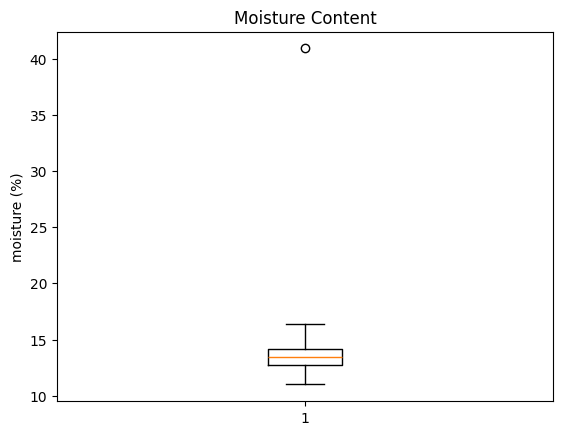

In [18]:
# moisture stats
print(f'mean moisture: {w["moisture"].mean():.4f}')
print(f'std moisture: {w["moisture"].std():.4f}')

# boxplot - theres obviously one mega outlier lol
plt.boxplot(w['moisture'])
plt.ylabel('moisture (%)')
plt.title('Moisture Content');


When you look at the data, it is obvious that there is one outlier.

- Create a new boxplot for all the data except for the one outlier (*for example by making a boxplot for all moisture data below 30*). Make sure you choose correct limits for the vertical axis, so that the whiskers are visible.

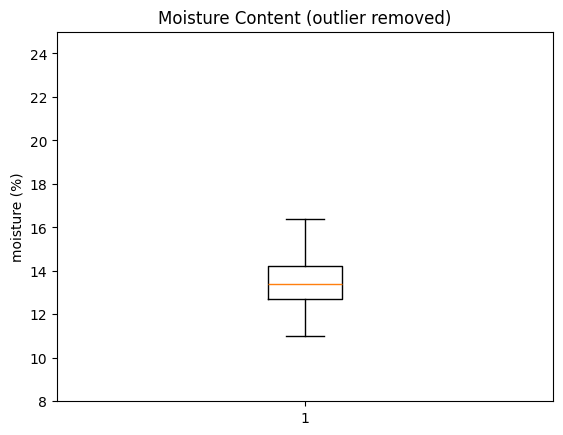

In [19]:
# boxplot without the outlier (keeping moisture < 30 only)
moisture_clean = w['moisture'][w['moisture'] < 30]
plt.boxplot(moisture_clean)
plt.ylabel('moisture (%)')
plt.ylim(8, 25)  # zoom in so whiskers are visible
plt.title('Moisture Content (outlier removed)');


### Q9. Histogram of bending strength

- Create a histogram of the bending strength. Add labels to the axes.

- Does the histogram look like a Normal distribution?

- On the same graph draw *a red vertical line* for the experimentally determined 5% bending strength.

- Print the 0.05 experimental quantile bending strength to the screen.

0.05 experimental quantile bending strength: 22.4125


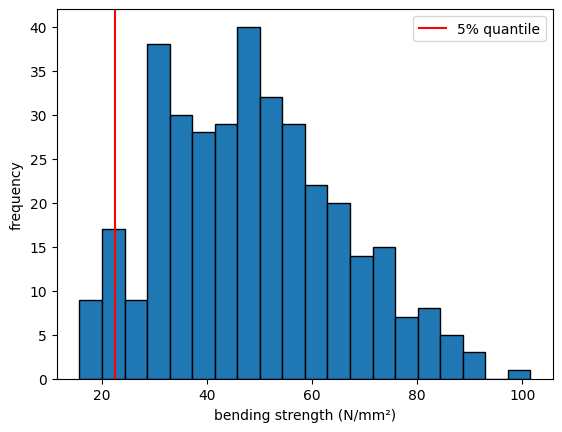

In [20]:
# histogram of bending strength
plt.hist(w['bstrength'], bins=20, edgecolor='black')

# it looks roughly normal-ish, kinda bell shaped

# 5% quantile
q05 = w['bstrength'].quantile(0.05)
print(f'0.05 experimental quantile bending strength: {q05:.4f}')

# red vertical line at 5% value
plt.axvline(q05, color='red', label='5% quantile')
plt.xlabel('bending strength (N/mm²)')
plt.ylabel('frequency')
plt.legend();


### Q10. Normal distribution for bending strength

Let's try to fit a normal distribution to the bending strength data. This is obviously not quite correct, as the tail of the Normal distribution will extend below zero to the left, which is unrealistic. However, if the part of the tail below zero is small, this may be a reasonable first step.

- Create a normalized histogram of the bending strength.
- Add a red vertical line for the 5% bending strength according to the data.


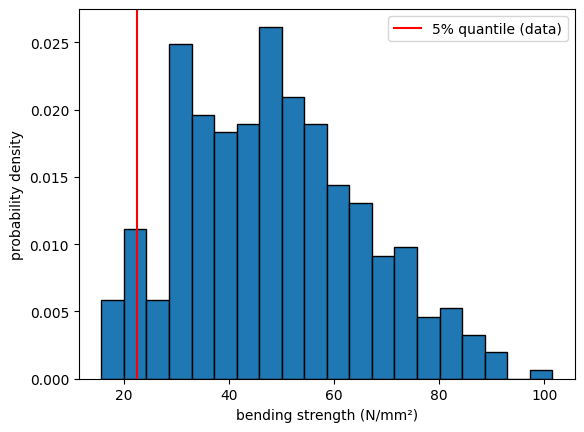

In [21]:
from scipy.stats import norm

# normalized histogram
plt.hist(w['bstrength'], bins=20, density=True, edgecolor='black')

# red line for 5% bending strength from data
plt.axvline(q05, color='red', label='5% quantile (data)')

plt.xlabel('bending strength (N/mm²)')
plt.ylabel('probability density')
plt.legend();


- Compute the mean and standard deviation of the bending strength data and plot on the same graph the Normal probability density function using these estimates of the mean and standard deviation.
- Add a black vertical line for the 5% bending strength according to the fitted Normal distribution

5% bending strength from data: 22.4125
5% bending strength from normal fit: 20.6090


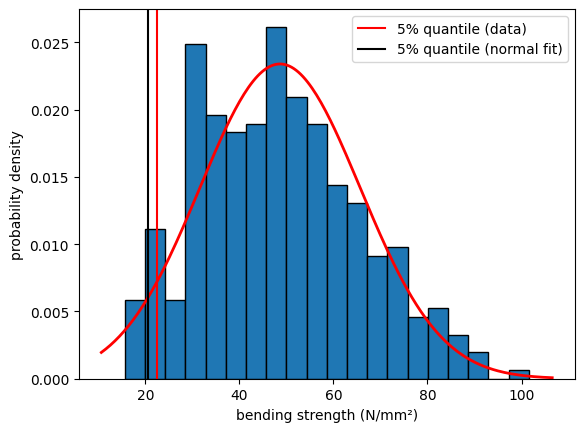

In [22]:
# fit normal to bending strength data
mu_bs = w['bstrength'].mean()
sig_bs = w['bstrength'].std()

# normalized histogram
plt.hist(w['bstrength'], bins=20, density=True, edgecolor='black')

# red normal pdf overlay
x_bs = np.linspace(w['bstrength'].min() - 5, w['bstrength'].max() + 5, 200)
plt.plot(x_bs, norm.pdf(x_bs, mu_bs, sig_bs), 'r-', linewidth=2)

# red line for empirical 5%
plt.axvline(q05, color='red', label='5% quantile (data)')

# black line for 5% from fitted normal
q05_normal = norm.ppf(0.05, mu_bs, sig_bs)
plt.axvline(q05_normal, color='black', label='5% quantile (normal fit)')

plt.xlabel('bending strength (N/mm²)')
plt.ylabel('probability density')
plt.legend()

print(f'5% bending strength from data: {q05:.4f}')
print(f'5% bending strength from normal fit: {q05_normal:.4f}')
